In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from EMDPM.visualization import *
from EMDPM.utils import solve_system
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, kendalltau
import os
import glob

# Find all grid search result files
result_dir = "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/2026_2_16_adni_subtyping_bic/results"
pattern = os.path.join(result_dir, "PPMI_subtyping_grid_*.npz")
paths = sorted(glob.glob(pattern))
print(f"Found {len(paths)} result files")

def load_results(paths):
    results = {}
    for path in paths:
        key = os.path.splitext(os.path.basename(path))[0]
        try:
            data = np.load(path, allow_pickle=True)
            results[key] = data
        except Exception as e:
            print(f"Error loading {key}: {e}")
    return results

results = load_results(paths)
print(f"\nTotal loaded: {len(results)} results")



Found 416 result files

Total loaded: 416 results


In [17]:
# Extract summary statistics for all models
n_biomarkers = 68
summary = []

for cand, data in results.items():
    try:
        # Extract final values
        final_lse = data["lse_history"][-1] if "lse_history" in data.files else np.nan

        # Extract cluster parameters
        if "cluster_f" in data.files:
            cluster_f = data["cluster_f"]
            n_subtypes = cluster_f.shape[0]
            # Sparsity: count of f entries below 0.01 (across all clusters)
            f_sparsity = int(np.sum(cluster_f < 0.01))
        else:
            cluster_f = None
            n_subtypes = 0
            f_sparsity = np.nan

        final_scalar_K = data["final_scalar_K"] if "final_scalar_K" in data.files else np.nan
        final_s = data["final_s"] if "final_s" in data.files else np.nan

        # Extract candidate number
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])

        # Extract lambda parameters
        lambda_cog = data["lambda_cog"] if "lambda_cog" in data.files else np.nan
        lambda_jsd = data["lambda_jsd"] if "lambda_jsd" in data.files else np.nan
        lambda_f = data["lambda_f"] if "lambda_f" in data.files else np.nan
        lambda_scalar = data["lambda_scalar"] if "lambda_scalar" in data.files else np.nan

        # Extract assignment statistics
        if "final_assignments" in data.files:
            assignments = data["final_assignments"]
            subtype_counts = np.bincount(assignments, minlength=n_subtypes) if n_subtypes > 0 else []
        else:
            subtype_counts = []

        bic = float(data["bic"]) if "bic" in data.files else np.nan
        cv_mean_lse = float(data["cv_mean_lse"]) if "cv_mean_lse" in data.files else np.nan

        summary.append({
            "candidate": candidate_num,
            "key": cand,
            "final_lse": final_lse,
            "cv_mean_lse": cv_mean_lse,
            "bic": bic,
            "n_subtypes": n_subtypes,
            "scalar_K": final_scalar_K,
            "mean_s": np.mean(final_s) if isinstance(final_s, np.ndarray) else final_s,
            "lambda_cog": lambda_cog,
            "lambda_jsd": lambda_jsd,
            "lambda_f": lambda_f,
            "lambda_scalar": lambda_scalar,
            "f_sparsity": f_sparsity,
            "subtype0_count": subtype_counts[0] if len(subtype_counts) > 0 else np.nan,
            "subtype1_count": subtype_counts[1] if len(subtype_counts) > 1 else np.nan,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values("cv_mean_lse").reset_index(drop=True)
print("\nSummary Statistics (sorted by CV LSE)")
print(summary_df[["candidate", "final_lse", "cv_mean_lse", "bic", "n_subtypes", "scalar_K", "mean_s", "lambda_cog", "lambda_jsd", "lambda_f", "lambda_scalar", "f_sparsity"]].head(10))


Summary Statistics (sorted by CV LSE)
  candidate    final_lse  cv_mean_lse            bic  n_subtypes  \
0        64  5763.261522  2198.133039 -100967.261648           2   
1        61  5793.372067  2202.106702 -100045.962837           2   
2        63  5818.184648  2207.071769  -99290.358562           2   
3       131  5687.608467  2215.870837 -103303.443048           2   
4       132  5665.121763  2220.285529 -104003.830423           2   
5        14  6600.393048  2289.674840  -76988.646904           2   
6        74  5739.112680  2318.128968 -101709.633881           2   
7         4  7441.608990  2326.377890  -55780.092373           2   
8        17  6534.667410  2335.717852  -78758.016727           2   
9       134  7498.147878  2336.727143  -54441.901501           2   

              scalar_K    mean_s lambda_cog lambda_jsd lambda_f lambda_scalar  \
0                  0.0  0.819669        0.0       1000      1.2           0.6   
1                  0.0  0.819175        0.0       

### MODEL SELECTION

In [18]:
inspect_candidate = 17
#inspect_candidate = 186

if inspect_candidate is None:
    # 2-stage selection
    # Stage 1: For each K (n_subtypes), pick hyperparameters with lowest CV LSE
    # Stage 2: Among those best-per-K models, pick the one with best (lowest) BIC
    df_bic = summary_df[summary_df["bic"].notna()].copy()
    if len(df_bic) == 0:
        best_row = summary_df.sort_values("cv_mean_lse").iloc[0]
        best_key = best_row["key"]
        best_data = results[best_key]
        print("\nBEST MODEL (by CV LSE, no BIC in results)")
    else:
        best_per_K = df_bic.loc[df_bic.groupby("n_subtypes")["cv_mean_lse"].idxmin()]
        idx_best = best_per_K["bic"].idxmin()
        best_row = best_per_K.loc[idx_best]
        best_key = best_row["key"]
        best_data = results[best_key]
        print("\nBEST MODEL (2-stage: best CV LSE per K, then best BIC among those)")
        print("Stage 1 - Best per K (by CV LSE):")
        for _, r in best_per_K.sort_values("n_subtypes").iterrows():
            print(f"  K={int(r['n_subtypes'])}: candidate={r['candidate']}, cv_mean_lse={r['cv_mean_lse']:.6f}, bic={r['bic']:.4f}")
        print(f"\nStage 2 - Selected K={int(best_row['n_subtypes'])} (lowest BIC among above).")
else:
    # Inspect specific candidate
    match = summary_df[summary_df["candidate"] == inspect_candidate]
    if len(match) == 0:
        raise ValueError(f"No result found for candidate {inspect_candidate}")
    best_row = match.iloc[0]
    best_key = best_row["key"]
    best_data = results[best_key]
    print(f"\nINSPECTING CANDIDATE {inspect_candidate} (best_* set to this run)")

print(f"Key: {best_key}")
print(f"n_subtypes: {best_row['n_subtypes']}, Final LSE: {best_row['final_lse']:.6f}")
if "bic" in best_row and pd.notna(best_row["bic"]):
    print(f"BIC: {best_row['bic']:.4f}, CV mean LSE: {best_row['cv_mean_lse']:.6f}")
if "lambda_f" in best_data.files:
    print(f"\nParameters:")
    print(f"  lambda_f: {best_data['lambda_f']}")
    print(f"  lambda_cog: {best_data['lambda_cog']}")
    print(f"  lambda_scalar: {best_data['lambda_scalar']}")
    print(f"  lambda_jsd: {best_data['lambda_jsd']}")
    print(f"  lambda_beta: {best_data['lambda_beta']}")


INSPECTING CANDIDATE 17 (best_* set to this run)
Key: PPMI_subtyping_grid_betajsd_017_lambda_f1p000_lambda_cog0p000_lambda_scalar1p200_lambda_jsd50_lambda_beta0p000_n_subtypes2
n_subtypes: 2, Final LSE: 6534.667410
BIC: -78758.0167, CV mean LSE: 2335.717852

Parameters:
  lambda_f: 1.0
  lambda_cog: 0.0
  lambda_scalar: 1.2
  lambda_jsd: 50
  lambda_beta: 0.0


In [19]:
# Find best candidates for transform LSE (with and without cognitive priors)
transform_summary = []

for cand, data in results.items():
    try:
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])
        
        # Extract validation LSE values
        val_lse_with_cog = data["val_lse_with_cog"] if "val_lse_with_cog" in data.files else np.nan
        val_lse_no_cog = data["val_lse_no_cog"] if "val_lse_no_cog" in data.files else np.nan
        
        # Extract parameters
        lambda_f = data["lambda_f"] if "lambda_f" in data.files else np.nan
        lambda_cog = data["lambda_cog"] if "lambda_cog" in data.files else np.nan
        lambda_scalar = data["lambda_scalar"] if "lambda_scalar" in data.files else np.nan
        lambda_jsd = data["lambda_jsd"] if "lambda_jsd" in data.files else np.nan
        lambda_beta = data["lambda_beta"] if "lambda_beta" in data.files else np.nan
        
        transform_summary.append({
            "candidate": candidate_num,
            "key": cand,
            "val_lse_with_cog": val_lse_with_cog,
            "val_lse_no_cog": val_lse_no_cog,
            "lambda_f": lambda_f,
            "lambda_cog": lambda_cog,
            "lambda_scalar": lambda_scalar,
            "lambda_jsd": lambda_jsd,
            "lambda_beta": lambda_beta,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

transform_df = pd.DataFrame(transform_summary)

print(transform_df.shape)


(416, 9)


In [20]:
# Use the best model (lowest training LSE) for both with and without cognitive priors
print(f"Key: {best_key}")
print(f"Training LSE: {best_row['final_lse']:.6f}")

# Get validation LSE values from best_data if available
val_lse_with_cog = best_data["val_lse_with_cog"] if "val_lse_with_cog" in best_data.files else np.nan
val_lse_no_cog = best_data["val_lse_no_cog"] if "val_lse_no_cog" in best_data.files else np.nan

print(f"Validation LSE (with cog): {val_lse_with_cog:.6f}")
print(f"Validation LSE (no cog): {val_lse_no_cog:.6f}")

if "lambda_f" in best_data.files:
    print(f"\nParameters:")
    print(f"  lambda_f: {best_data['lambda_f']}")
    print(f"  lambda_cog: {best_data['lambda_cog']}")
    print(f"  lambda_scalar: {best_data['lambda_scalar']}")
    print(f"  lambda_jsd: {best_data['lambda_jsd']}")
    print(f"  lambda_beta: {best_data['lambda_beta']}")

# Get subtype assignments from best_data
train_assignments = best_data['train_assignments']
val_with = best_data['val_assignments_with_cog'] if 'val_assignments_with_cog' in best_data.files else []
val_no = best_data['val_assignments_no_cog'] if 'val_assignments_no_cog' in best_data.files else []
n_subtypes = len(np.unique(train_assignments))

print(f"\nTraining Set")
print(f"Subtype counts:")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(train_assignments == k)} patients")
print(f"  Total: {len(train_assignments)} patients")

print(f"\nValidation Set")
print(f"Subtype counts (with cog):")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(val_with == k)} patients")
print(f"  Total: {len(val_with)} patients")

print(f"\nSubtype counts (no cog):")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(val_no == k)} patients")
print(f"  Total: {len(val_no)} patients")

Key: PPMI_subtyping_grid_betajsd_017_lambda_f1p000_lambda_cog0p000_lambda_scalar1p200_lambda_jsd50_lambda_beta0p000_n_subtypes2
Training LSE: 6534.667410
Validation LSE (with cog): 1982.805744
Validation LSE (no cog): 1982.805744

Parameters:
  lambda_f: 1.0
  lambda_cog: 0.0
  lambda_scalar: 1.2
  lambda_jsd: 50
  lambda_beta: 0.0

Training Set
Subtype counts:
  Subtype 0: 497 patients
  Subtype 1: 325 patients
  Total: 822 patients

Validation Set
Subtype counts (with cog):
  Subtype 0: 63 patients
  Subtype 1: 143 patients
  Total: 206 patients

Subtype counts (no cog):
  Subtype 0: 63 patients
  Subtype 1: 143 patients
  Total: 206 patients


### hist of transform LSE differences

/tmp/ipykernel_18430/741470681.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


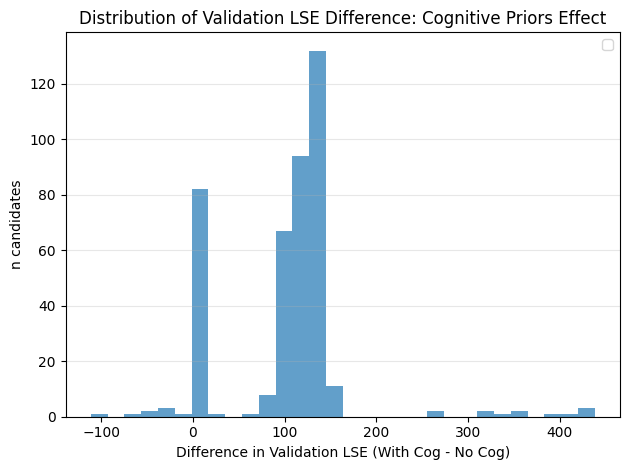

8 328


In [21]:
transform_df["lse_diff"] = transform_df["val_lse_with_cog"] - transform_df["val_lse_no_cog"]
valid_diff = transform_df.dropna(subset=["lse_diff"])

# Plot histogram
plt.hist(valid_diff['lse_diff'], bins=30, alpha=0.7)
plt.xlabel('Difference in Validation LSE (With Cog - No Cog)')
plt.ylabel('n candidates')
plt.title('Distribution of Validation LSE Difference: Cognitive Priors Effect')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

n_better_with_cog = (valid_diff['lse_diff'] < 0).sum()
n_worse_with_cog = (valid_diff['lse_diff'] > 0).sum()
print(n_better_with_cog, n_worse_with_cog)    

In [22]:
# Load PPMI data for analysis
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")
## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

subj_counts = df['subj_id'].value_counts()
longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
print(f"max(X_obs): {np.max(X_obs)}")

X_obs = np.max(X_obs, axis=0) - X_obs

## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

print(f"max(K): {np.max(K)}")
print(f"median(K>0): {np.median(K[K>0])}")
print(f"mean(K>0): {np.mean(K[K>0])}")

t_max = 40
t_span = np.linspace(0, t_max, int(t_max/0.01))

biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# Extract arrays for analysis
ids_all = df["subj_id"].to_numpy()
dt_all = df["time"].to_numpy()/12  # convert to years
nhy_all = df["NHY"].to_numpy()
cog_all = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()
df["NSD_STAGE"] = df["NSD_STAGE"].replace({"Not NSD": 0, "2b": 2})
df["NSD_STAGE"] = pd.to_numeric(df["NSD_STAGE"], errors='coerce')
nsd = df["NSD_STAGE"].to_numpy()

print(f"Loaded data: {X_obs.shape}, K: {K.shape}, biomarkers: {len(biomarker_names)}")
print(f"Patients: {len(np.unique(ids_all))}, Observations: {len(ids_all)}")


original size: (880, 250)
max(X_obs): 4.149
max(K): 0.7092698941919034
median(K>0): 0.05660444668080453
mean(K>0): 0.08089973514944429
Loaded data: (504, 68), K: (68, 68), biomarkers: 68
Patients: 146, Observations: 504


In [23]:
# Extract best model assignments and betas
train_ids = best_data["train_ids"]
val_ids = best_data["val_ids"] if "val_ids" in best_data.files else []
beta_train = best_data["beta_history"][:, -1]
beta_val = best_data["beta_val"] if "beta_val" in best_data.files else []

print(f"Training patients: {len(train_ids)}")
print(f"Validation patients: {len(val_ids)}")

# Combine train and val
all_ids_list = list(train_ids) + list(val_ids)
all_betas_list = list(beta_train) + list(beta_val)
pid_to_beta = {pid: beta for pid, beta in zip(all_ids_list, all_betas_list)}

train_assignments = best_data["train_assignments"]
val_assignments = best_data["val_assignments"] if "val_assignments" in best_data.files else []
all_assignments_list = list(train_assignments) + list(val_assignments)
pid_to_assignment = {pid: assign for pid, assign in zip(all_ids_list, all_assignments_list)}

# Get beta values and assignments aligned with ids_all
beta_all = np.array([pid_to_beta.get(pid, np.nan) for pid in ids_all])
assignment_all = np.array([pid_to_assignment.get(pid, -1) for pid in ids_all])

# Filter to valid patients
valid_mask = np.array([pid in pid_to_beta for pid in ids_all])
ids_valid = ids_all[valid_mask]
beta_valid = beta_all[valid_mask]
assignment_valid = assignment_all[valid_mask]
nhy_valid = nhy_all[valid_mask]
nsd_valid = nsd[valid_mask]
cog_valid = cog_all[valid_mask]

# Count unique patients per subtype (not observations!)
unique_valid_pids = np.unique(ids_valid)
patient_assignments = np.array([pid_to_assignment.get(pid, -1) for pid in unique_valid_pids])

n_subtypes = len(np.unique(patient_assignments[patient_assignments >= 0]))
print(f"Total subject: {len(unique_valid_pids)}\n")
for k in range(n_subtypes):
    print(f"Subtype {k}: {np.sum(patient_assignments == k)} patients")

# Breakdown by train vs validation
train_patient_assignments = np.array([pid_to_assignment.get(pid, -1) for pid in train_ids])
val_patient_assignments = np.array([pid_to_assignment.get(pid, -1) for pid in val_ids])

print(f"\nTraining set:")
print(f"  Total: {len(train_ids)} patients")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(train_patient_assignments == k)} patients")

print(f"\nValidation set:")
print(f"  Total: {len(val_ids)} patients")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(val_patient_assignments == k)} patients")

Training patients: 822
Validation patients: 206
Total subject: 0


Training set:
  Total: 822 patients

Validation set:
  Total: 206 patients



Subtype 0:
  Intercept (cog_b): 34.7384
  MCATOT coefficient: -1.1337
  TD_score coefficient: -0.3089
  PIGD_score coefficient: 0.6097
s_ij = 34.7384 +-1.1337 * MCATOT +-0.3089 * TD +0.6097 * PIGD

Subtype 1:
  Intercept (cog_b): 26.2029
  MCATOT coefficient: -0.5238
  TD_score coefficient: -0.7376
  PIGD_score coefficient: 0.8421
s_ij = 26.2029 +-0.5238 * MCATOT +-0.7376 * TD +0.8421 * PIGD

Subtype 0:
  Intercept (cog_b): 34.7384
  MMSE coefficient: -1.1337
  ADAS11 coefficient: -0.3089
  ADAS13 coefficient: 0.6097
s_ij = 34.7384 +-1.1337 * MCATOT +-0.3089 * TD +0.6097 * PIGD

Subtype 1:
  Intercept (cog_b): 26.2029
  MMSE coefficient: -0.5238
  ADAS11 coefficient: -0.7376
  ADAS13 coefficient: 0.8421
s_ij = 26.2029 +-0.5238 * MCATOT +-0.7376 * TD +0.8421 * PIGD


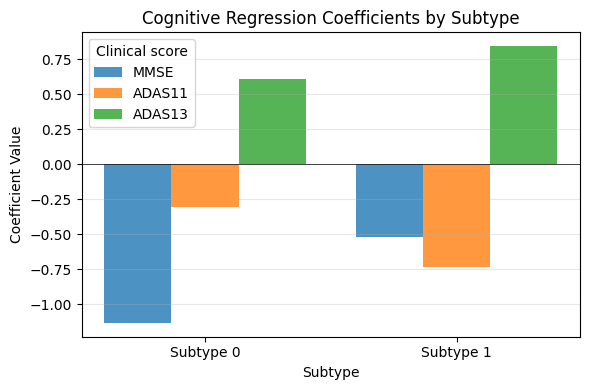

In [24]:
# Cognitive Parameter Comparison (general for any number of subtypes from best model)
cluster_cog_a = np.asarray(best_data["cluster_cog_a"])  # (n_subtypes, n_cog_features)
cluster_cog_b = np.atleast_1d(np.asarray(best_data["cluster_cog_b"]))  # (n_subtypes,)
n_subtypes = cluster_cog_b.shape[0]  # derive from data so it matches loaded arrays

cog_feature_names = ['MCATOT', 'TD_score', 'PIGD_score']

for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    print(f"  Intercept (cog_b): {cluster_cog_b[subtype]:.4f}")
    for i, name in enumerate(cog_feature_names):
        print(f"  {name} coefficient: {cluster_cog_a[subtype, i]:.4f}")

    print(f"s_ij = {cluster_cog_b[subtype]:.4f} +\
{cluster_cog_a[subtype, 0]:.4f} * MCATOT +\
{cluster_cog_a[subtype, 1]:.4f} * TD +\
{cluster_cog_a[subtype, 2]:.4f} * PIGD")


# Cognitive Parameter Comparison (general for any number of subtypes from best model)
cluster_cog_a = np.asarray(best_data["cluster_cog_a"])  # (n_subtypes, n_cog_features)
cluster_cog_b = np.atleast_1d(np.asarray(best_data["cluster_cog_b"]))  # (n_subtypes,)
n_subtypes = cluster_cog_b.shape[0]  # derive from data so it matches loaded arrays

cog_feature_names = ['MMSE', 'ADAS11', 'ADAS13']

for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    print(f"  Intercept (cog_b): {cluster_cog_b[subtype]:.4f}")
    for i, name in enumerate(cog_feature_names):
        print(f"  {name} coefficient: {cluster_cog_a[subtype, i]:.4f}")

    print(f"s_ij = {cluster_cog_b[subtype]:.4f} +\
{cluster_cog_a[subtype, 0]:.4f} * MCATOT +\
{cluster_cog_a[subtype, 1]:.4f} * TD +\
{cluster_cog_a[subtype, 2]:.4f} * PIGD")


fig, ax = plt.subplots(1, 1, figsize=(6, 4))
x = np.arange(n_subtypes)
width = 0.8 / len(cog_feature_names)
for feat_idx, feat_name in enumerate(cog_feature_names):
    offset = (feat_idx - (len(cog_feature_names) - 1) / 2) * width
    values = cluster_cog_a[:, feat_idx]
    ax.bar(x + offset, values, width, label=feat_name, alpha=0.8)
ax.set_xlabel('Subtype')
ax.set_ylabel('Coefficient Value')
ax.set_title('Cognitive Regression Coefficients by Subtype')
ax.set_xticks(x)
ax.set_xticklabels([f'Subtype {s}' for s in range(n_subtypes)])
ax.legend(title='Clinical score')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

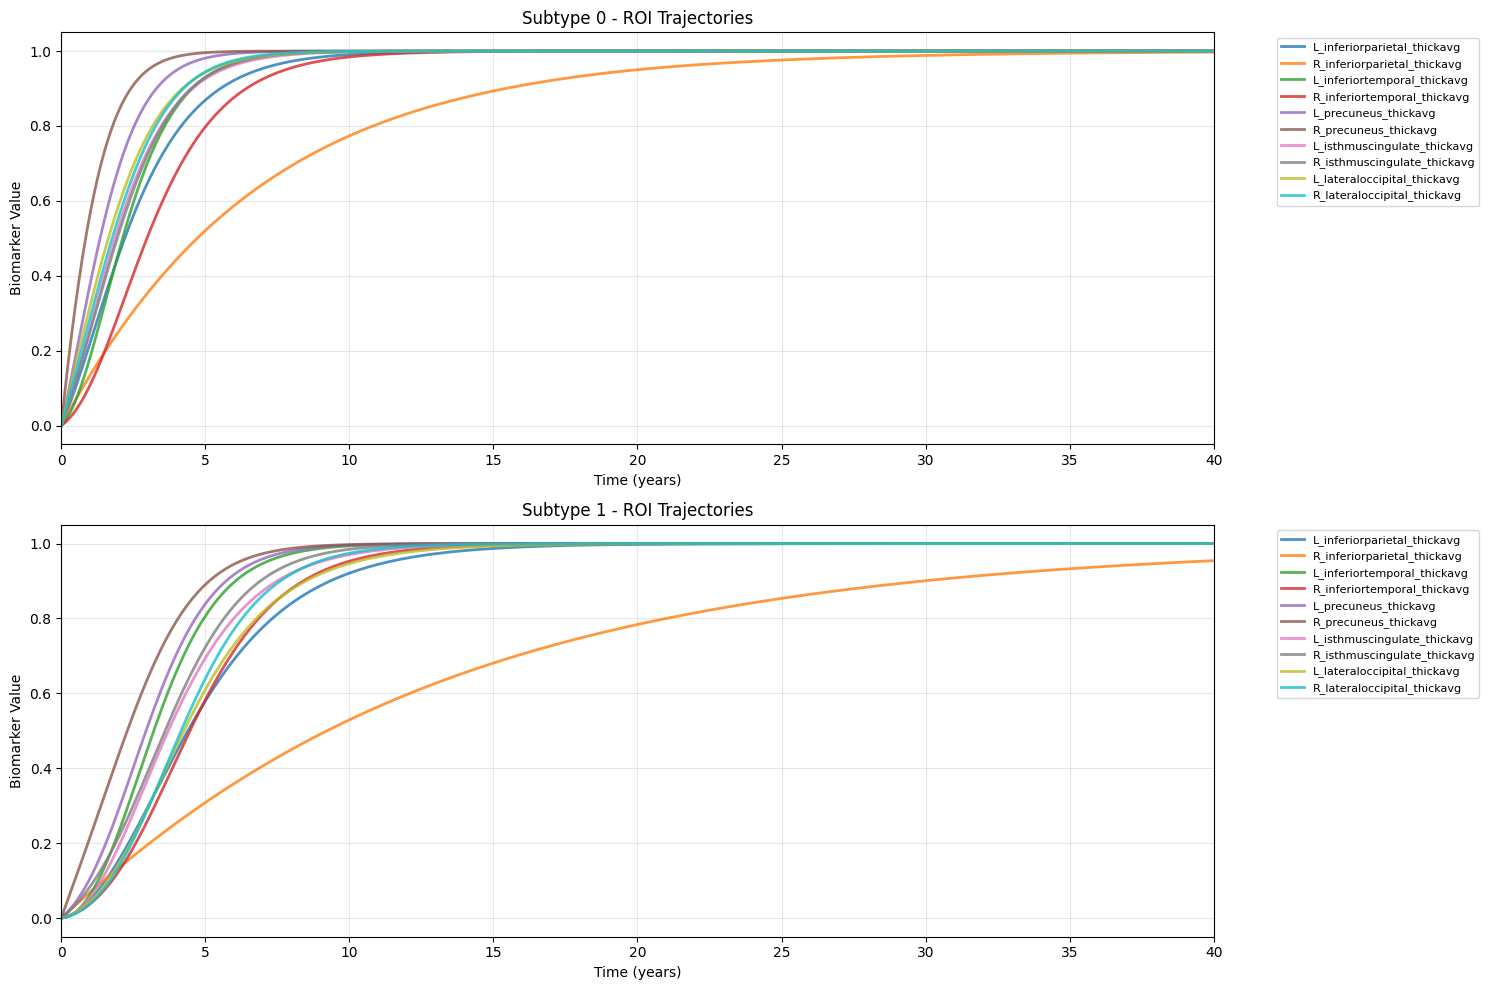

In [25]:
# ROI Subplots: 10 ROI trajectories for each subtype
cluster_f = best_data["cluster_f"]
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5 * n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K)

    ax = axes[subtype]
    for i, roi_idx in enumerate(ROI):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=ROI_names[i], linewidth=2, alpha=0.8)

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype} - ROI Trajectories")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()

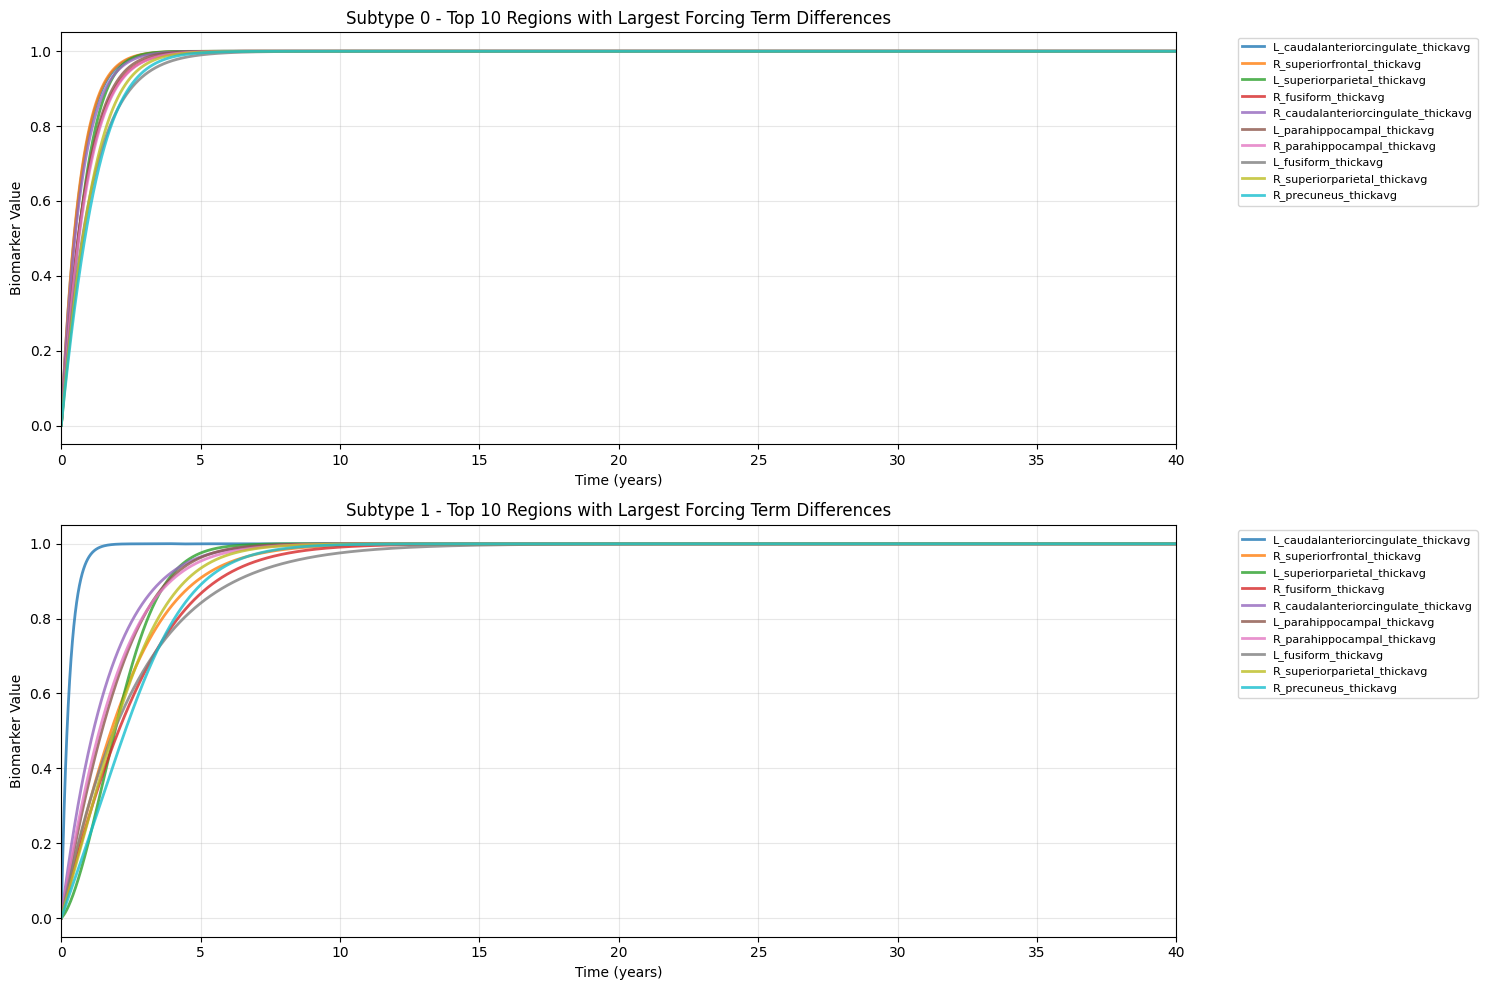

In [26]:
# ROI Subplots: Top 10 regions with largest forcing term differences

cluster_f = best_data["cluster_f"] # (n_subtypes, n_biomarkers)
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

# Per-ROI difference across all subtypes (works for any n_subtypes)
f_diff_max = np.zeros(n_biomarkers)
for i in range(n_subtypes):
    for j in range(i + 1, n_subtypes):
        f_diff_max = np.maximum(f_diff_max, np.abs(cluster_f[i] - cluster_f[j]))

top_n = 10
top_indices = np.argsort(f_diff_max)[-top_n:][::-1]
top_ROI_names = [biomarker_names[idx] for idx in top_indices]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

# Plot trajectories for each subtype
fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5 * n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K)

    ax = axes[subtype]
    for i, roi_idx in enumerate(top_indices):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=top_ROI_names[i], linewidth=2, alpha=0.8)

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype} - Top 10 Regions with Largest Forcing Term Differences")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()

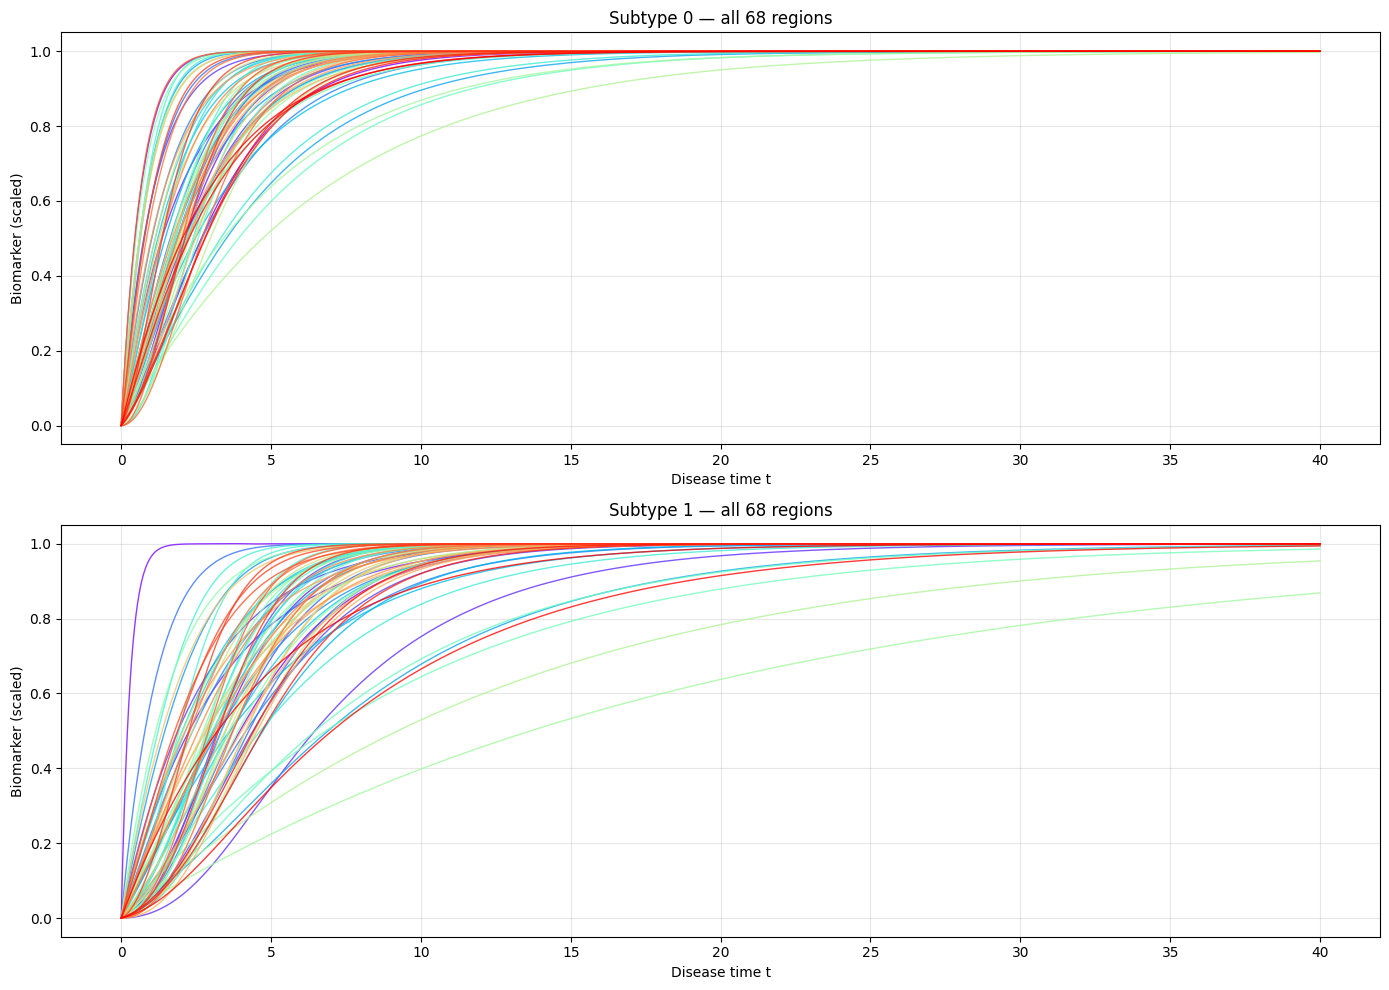

In [27]:
# Plot all 68 brain regions for each subtype (no legend; max-distinct colors)
import numpy as np
import matplotlib.pyplot as plt
from EMDPM.utils import solve_system

cluster_f = best_data["cluster_f"]
final_s = best_data["final_s"]
final_scalar_K = best_data["final_scalar_K"]
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

# 68 distinct colors (rainbow-like)
colors = plt.cm.rainbow(np.linspace(0, 1, n_biomarkers))

fig, axes = plt.subplots(n_subtypes, 1, figsize=(14, 5 * n_subtypes))
if n_subtypes == 1:
    axes = [axes]
for subtype, ax in enumerate(axes):
    f_subtype = np.ravel(cluster_f[subtype])
    x0 = np.zeros(n_biomarkers)
    Xtraj = solve_system(x0, f_subtype, K, t_span, final_scalar_K)
    for b in range(n_biomarkers):
        traj = Xtraj[b] #* final_s[b]
        ax.plot(t_span, traj, color=colors[b], alpha=0.8, linewidth=1)
    ax.set_xlabel("Disease time t")
    ax.set_ylabel("Biomarker (scaled)")
    ax.set_title(f"Subtype {subtype} — all {n_biomarkers} regions")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Subtype 0 Beta Statistics:
  Mean: nan
  Median: nan
  Std: nan

Subtype 1 Beta Statistics:
  Mean: nan
  Median: nan
  Std: nan


/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


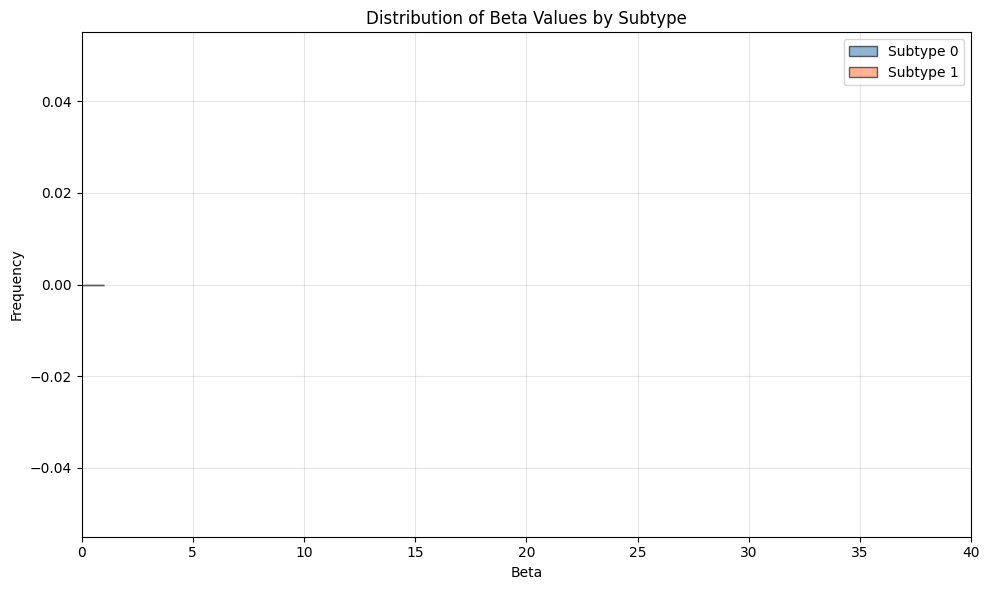

In [28]:
# Beta distributions by subtype
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral', 'forestgreen', 'purple']
for subtype in range(n_subtypes):
    beta_subtype = beta_valid[assignment_valid == subtype]
    plt.hist(beta_subtype, bins=30, alpha=0.6, label=f'Subtype {subtype}', 
             color=colors[subtype], edgecolor='black')
    print(f"\nSubtype {subtype} Beta Statistics:")
    print(f"  Mean: {np.mean(beta_subtype):.4f}")
    print(f"  Median: {np.median(beta_subtype):.4f}")
    print(f"  Std: {np.std(beta_subtype):.4f}")

plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.title("Distribution of Beta Values by Subtype")
plt.xlim(0, 40)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


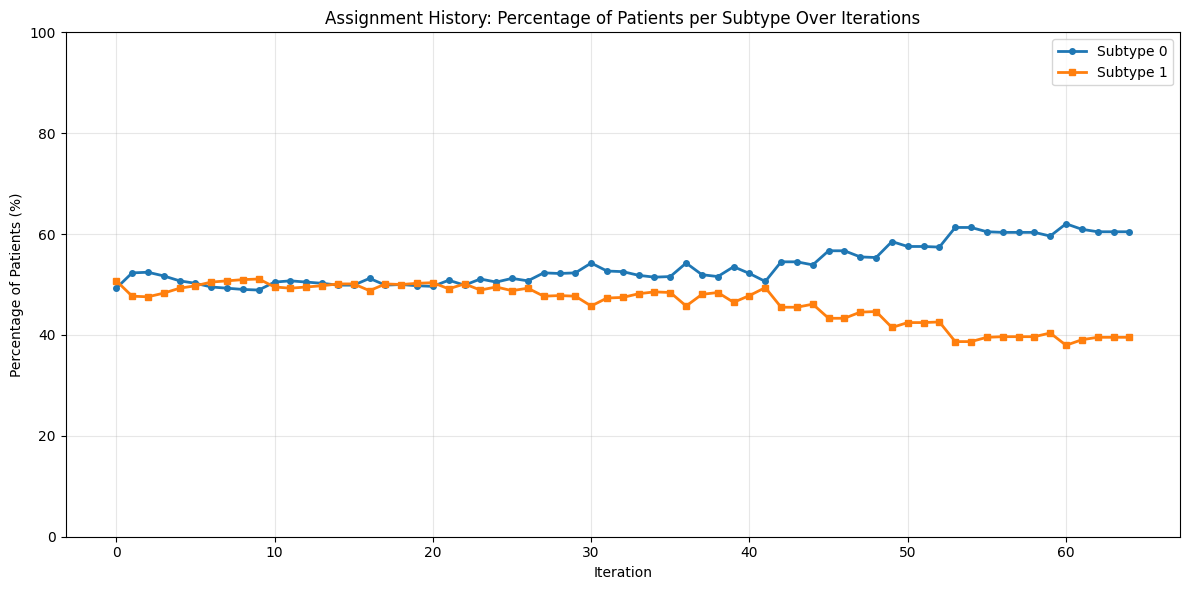

In [29]:
# Plot assignment history over iterations
if "assignment_history" in best_data.files:
    assignment_history = best_data["assignment_history"]  # (n_patients, n_iterations+1)
    n_iterations = assignment_history.shape[1] - 1
    
    # Calculate percentage of subtype 0 and 1 for each iteration
    pct_subtype0 = []
    pct_subtype1 = []
    
    for iter_idx in range(n_iterations + 1):
        assignments_iter = assignment_history[:, iter_idx]
        n_patients = len(assignments_iter)
        n_subtype0 = np.sum(assignments_iter == 0)
        n_subtype1 = np.sum(assignments_iter == 1)
        
        pct_subtype0.append(100 * n_subtype0 / n_patients)
        pct_subtype1.append(100 * n_subtype1 / n_patients)
    
    # Plot
    plt.figure(figsize=(12, 6))
    iterations = np.arange(n_iterations + 1)
    plt.plot(iterations, pct_subtype0, label='Subtype 0', linewidth=2, marker='o', markersize=4)
    plt.plot(iterations, pct_subtype1, label='Subtype 1', linewidth=2, marker='s', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Percentage of Patients (%)')
    plt.title('Assignment History: Percentage of Patients per Subtype Over Iterations')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

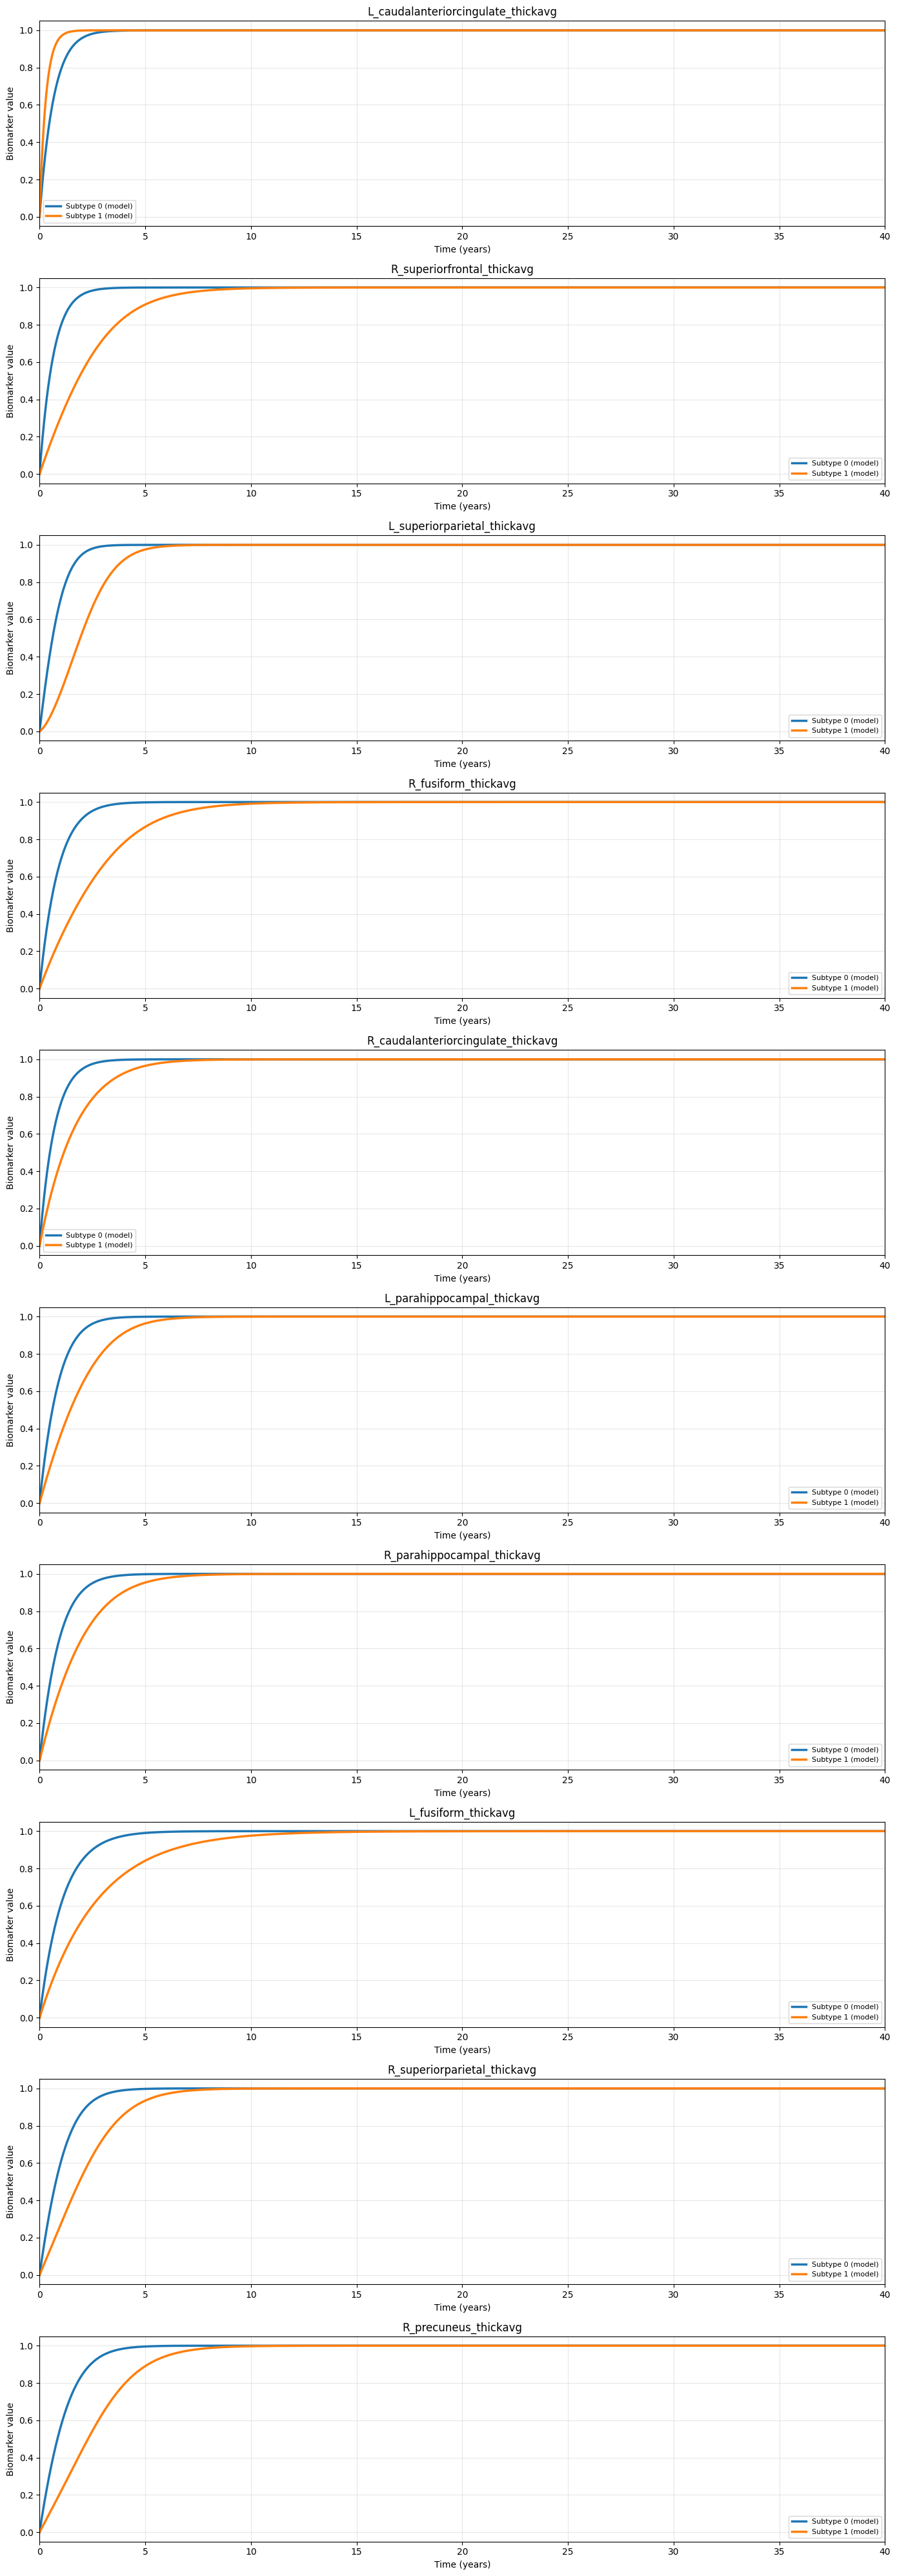

In [30]:
# Spaghetti plots: one subplot per region; patient trajectories (transparent) + model trajectories (solid) by subtype

import numpy as np
import matplotlib.pyplot as plt
from EMDPM.utils import solve_system

cluster_f = best_data["cluster_f"]
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

# Top regions by max forcing-term difference across subtypes (same as your ROI subplots)
f_diff_max = np.zeros(n_biomarkers)
for i in range(n_subtypes):
    for j in range(i + 1, n_subtypes):
        f_diff_max = np.maximum(f_diff_max, np.abs(cluster_f[i] - cluster_f[j]))
top_n = 10
top_indices = np.argsort(f_diff_max)[-top_n:][::-1]
top_ROI_names = [biomarker_names[idx] for idx in top_indices]

final_scalar_K = best_data["final_scalar_K"]
x0 = np.zeros(n_biomarkers)

# Subtype colors (solid for model; same color with alpha for spaghetti)
subtype_colors = plt.cm.tab10(np.arange(n_subtypes) / 10)
patient_alpha = 0.35

# Patients with a valid subtype assignment
pids_with_subtype = [p for p in np.unique(ids_all) if pid_to_assignment.get(p, -1) >= 0]
assignment_per_obs = np.array([pid_to_assignment.get(p, -1) for p in ids_all])

fig, axes = plt.subplots(len(top_indices), 1, figsize=(14, 4 * len(top_indices)))
if len(top_indices) == 1:
    axes = [axes]

for ax, roi_idx, roi_name in zip(axes, top_indices, top_ROI_names):
    # 1) Spaghetti: one line per patient (colored by subtype, transparent)
    for pid in pids_with_subtype:
        mask = ids_all == pid
        if mask.sum() < 2:
            continue
        beta_i = pid_to_beta.get(pid, np.nan)
        if np.isnan(beta_i):
            continue
        t_vals = dt_all[mask] + beta_i   # disease time: dt_ij + beta_i
        y_vals = X_obs[mask, roi_idx]
        order = np.argsort(t_vals)
        t_vals = t_vals[order]
        y_vals = y_vals[order]
        sub = pid_to_assignment.get(pid, -1)
        if sub < 0:
            continue
        ax.plot(t_vals, y_vals, color=subtype_colors[sub], alpha=patient_alpha, linewidth=1.5)

    # 2) Model trajectories (solid) for each subtype
    for subtype in range(n_subtypes):
        f_subtype = cluster_f[subtype]
        Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K)
        ax.plot(t_span, Xtraj_subtype[roi_idx], color=subtype_colors[subtype], linewidth=2.5, 
                label=f"Subtype {subtype} (model)")

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker value")
    ax.set_title(roi_name)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()